In [4]:
import pandas as pd

data = pd.read_csv("framingham.csv")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [7]:
data = pd.read_csv("framingham.csv")

# Preprocessing
data.drop(columns=['education'], inplace=True)
data.dropna(inplace=True)

# Features & Target
X = data.drop('TenYearCHD', axis=1)
y = data['TenYearCHD']


In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- TRAIN MODELS ----------------
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [ ]:
# ---------------- ACCURACY ----------------
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

print("✅ Model Accuracy:")
print(f"Logistic Regression: {lr_acc:.2f}")
print(f"Random Forest: {rf_acc:.2f}")

✅ Model Accuracy:
Logistic Regression: 0.83
Random Forest: 0.83



🔍 Enter Patient Details:
Gender (1=Male, 0=Female): 0
Age: 90
Smoker (1=Yes, 0=No): 1
Cigarettes per Day: 1
BP Medication (1=Yes, 0=No): 45
Stroke History (1=Yes, 0=No): 35
Hypertension (1=Yes, 0=No): 0
Diabetes (1=Yes, 0=No): 0
Cholesterol: 17
Systolic BP: 57
Diastolic BP: 35
BMI: 78
Heart Rate: 86
Glucose Level: 86

📊 ===== RESULT =====

🔹 Logistic Regression:
⚠️ High Risk
Probability: 1.00

🔹 Random Forest:
✅ Low Risk
Probability: 0.43


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x400 with 0 Axes>

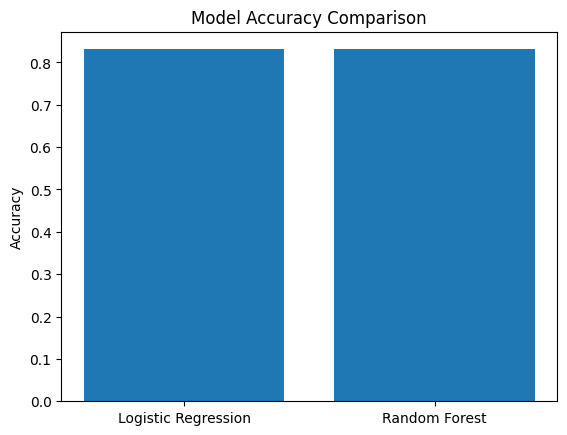

<Figure size 600x400 with 0 Axes>

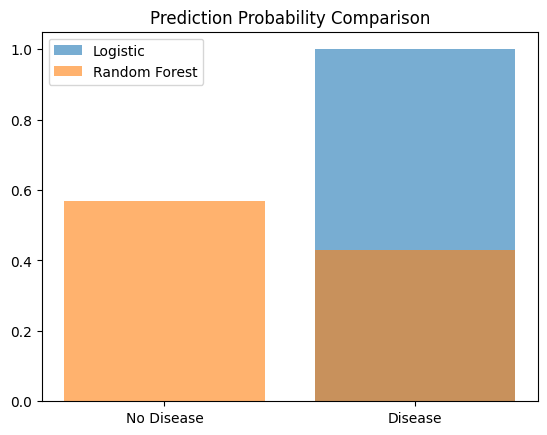

<Figure size 600x400 with 0 Axes>

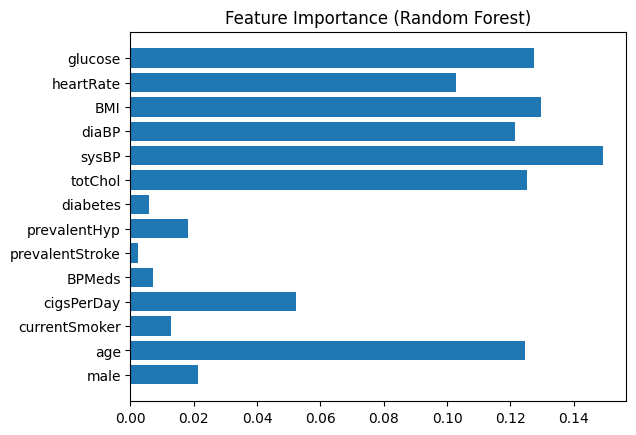

In [ ]:
# ---------------- USER INPUT ----------------
print("\n🔍 Enter Patient Details:")

male = int(input("Gender (1=Male, 0=Female): "))
age = int(input("Age: "))
currentSmoker = int(input("Smoker (1=Yes, 0=No): "))
cigsPerDay = int(input("Cigarettes per Day: "))
BPMeds = int(input("BP Medication (1=Yes, 0=No): "))
prevalentStroke = int(input("Stroke History (1=Yes, 0=No): "))
prevalentHyp = int(input("Hypertension (1=Yes, 0=No): "))
diabetes = int(input("Diabetes (1=Yes, 0=No): "))
totChol = int(input("Cholesterol: "))
sysBP = float(input("Systolic BP: "))
diaBP = float(input("Diastolic BP: "))
BMI = float(input("BMI: "))
heartRate = float(input("Heart Rate: "))
glucose = float(input("Glucose Level: "))

sample = np.array([[male, age, currentSmoker, cigsPerDay,
                    BPMeds, prevalentStroke, prevalentHyp, diabetes,
                    totChol, sysBP, diaBP, BMI, heartRate, glucose]])

# ---------------- PREDICTIONS ----------------
lr_pred = lr_model.predict(sample)[0]
rf_pred = rf_model.predict(sample)[0]

lr_prob = lr_model.predict_proba(sample)[0]
rf_prob = rf_model.predict_proba(sample)[0]






# ---------------- OUTPUT ----------------
print("\n📊 ===== RESULT =====")

print("\n🔹 Logistic Regression:")
if lr_pred == 1:
    print("⚠️ High Risk")
else:
    print("✅ Low Risk")
print(f"Probability: {lr_prob[1]:.2f}")

print("\n🔹 Random Forest:")
if rf_pred == 1:
    print("⚠️ High Risk")
else:
    print("✅ Low Risk")
print(f"Probability: {rf_prob[1]:.2f}")




import time

# ---------------- GRAPH 1: MODEL ACCURACY ----------------
print("📊 Showing Model Accuracy Comparison")
plt.figure(figsize=(6,4))
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

time.sleep(1)   # small gap

print("\n" + "="*50 + "\n")

# ---------------- GRAPH 2: PROBABILITY ----------------
print("📈 Showing Prediction Probability")
plt.figure()
plt.bar(labels, lr_prob, alpha=0.6, label="Logistic")
plt.bar(labels, rf_prob, alpha=0.6, label="Random Forest")
plt.title("Prediction Probability Comparison")
plt.legend()
plt.show()

time.sleep(1)

print("\n" + "="*50 + "\n")

# ---------------- GRAPH 3: FEATURE IMPORTANCE ----------------
print("🔍 Showing Feature Importance")
plt.figure(figsize=(6,4))
plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()
